# Task V - Quantum Graph Neural Network (QGNN)

This task delves into the design and implementation of a Quantum Graph Neural Network (QGNN) circuit using Google Cirq. The QGNN leverages the graph structure of data, encoding node features and edge connections into a quantum circuit.

## QGNN Circuit Concept
A QGNN circuit maps graph elements (nodes and edges) onto quantum states and operations:

-   **Node Encoding:** Each node in the graph is typically represented by a unique qubit. Node features (e.g., properties, attributes) are encoded into the quantum state of these qubits using single-qubit rotation gates (e.g., `Rx`, `Ry`, `Rz`). The rotation angles are often derived from the node features, allowing the quantum state to reflect the data.
-   **Edge Encoding (Entanglement Layer):** The connections (edges) between nodes are encoded using entangling gates (e.g., `CNOT`, `CZ`) between the qubits corresponding to the connected nodes. This creates quantum correlations between interacting nodes, simulating the flow of information across edges.
-   **Message Passing (Quantum Convolutional Layer):** Analogous to classical GNNs, quantum operations are applied to simulate message passing between nodes. This can involve controlled rotations or other multi-qubit gates that update the state of a qubit based on its entangled neighbors. These operations allow information to propagate through the graph structure.
-   **Readout (Measurement Layer):** After the quantum operations, measurements are performed on the qubits. The measurement outcomes can be used to extract node-level predictions (e.g., node classification) or aggregated for graph-level predictions (e.g., graph classification). The probabilities of different measurement outcomes constitute the network's output.

In [2]:
!pip install cirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 58.7 MB/s eta 0:00:00


In [3]:
import cirq
import matplotlib.pyplot as plt

In [5]:
# Example graph of 3 nodes, edges [(0,1), (1,2)]

def create_qgnn_circuit(node_features, edges):
    qubits = [cirq.GridQubit(0, i) for i in range(len(node_features))]
    circuit = cirq.Circuit()

    # Encode node features
    for i, feature in enumerate(node_features):
        circuit.append(cirq.rx(feature)(qubits[i]))

    # Encode edges with entanglement
    for edge in edges:
        circuit.append(cirq.CNOT(qubits[edge[0]], qubits[edge[1]]))

    # Message passing (example: controlled RY)
    for edge in edges:
        # Correct controlled RY usage
        circuit.append(cirq.ControlledGate(cirq.ry(0.5))(qubits[edge[0]], qubits[edge[1]]))
    # Readout
    for q in qubits:
        circuit.append(cirq.measure(q))
    return circuit, qubits

if __name__ == "__main__":
    node_features = [0.2, 0.5, 0.8]
    edges = [(0,1), (1,2)]
    circuit, qubits = create_qgnn_circuit(node_features, edges)
    print("QGNN Circuit:")
    print(circuit)


QGNN Circuit:
(0, 0): ───Rx(0.064π)───@───────@────────────M────────────────
                        │       │
(0, 1): ───Rx(0.159π)───X───@───Ry(0.159π)───@────────────M───
                            │                │
(0, 2): ───Rx(0.255π)───────X────────────────Ry(0.159π)───M───


Circuit diagram saved as task5/qgnn_circuit.svg


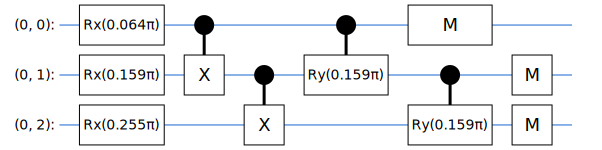

In [7]:
import matplotlib.pyplot as plt
import cirq
from cirq.contrib.svg import circuit_to_svg
from IPython.display import SVG

# Create a directory for saving the SVG if it doesn't exist
import os
output_dir = "task5"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the circuit as an SVG file
svg = circuit_to_svg(circuit)
with open(os.path.join(output_dir, "qgnn_circuit.svg"), "w", encoding="utf-8") as f:
    f.write(svg)
print(f"Circuit diagram saved as {os.path.join(output_dir, 'qgnn_circuit.svg')}")

# Display the circuit SVG directly in the notebook
display(SVG(svg))